In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory



# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models

from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

import umap.umap_ as umap

2026-06-03 08:46:14.284806: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780476374.514890      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780476374.578129      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780476375.104349      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780476375.104394      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780476375.104397      58 computation_placer.cc:177] computation placer alr

In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


In [4]:
DATASET_PATH = "/kaggle/input/datasets/abtinzandi/obstacle-detection-dataset/ROD-Dataset/dataset"

VALID_IMAGE_PATH = os.path.join(
    DATASET_PATH,
    "valid",
    "images"
)

print(VALID_IMAGE_PATH)



/kaggle/input/datasets/abtinzandi/obstacle-detection-dataset/ROD-Dataset/dataset/valid/images


In [5]:
analysis_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [6]:
class AnalysisDataset(Dataset):

    def __init__(self, image_dir, transform=None):

        self.transform = transform

        valid_extensions = (".jpg", ".jpeg", ".png")

        self.image_paths = [

            os.path.join(image_dir, img)

            for img in os.listdir(image_dir)

            if img.lower().endswith(valid_extensions)
        ]

    def __len__(self):

        return len(self.image_paths)

    def __getitem__(self, idx):

        img_path = self.image_paths[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, img_path

In [7]:
analysis_dataset = AnalysisDataset(
    VALID_IMAGE_PATH,
    transform=analysis_transform
)

analysis_loader = DataLoader(
    analysis_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

print("Validation Images:", len(analysis_dataset))

Validation Images: 3511


In [8]:
class ResNetSimCLR(nn.Module):

    def __init__(self, projection_dim=128):

        super().__init__()

        self.encoder = models.resnet18(weights=None)

        num_features = self.encoder.fc.in_features

        self.encoder.fc = nn.Identity()

        self.projector = nn.Sequential(

            nn.Linear(num_features, 512),

            nn.ReLU(),

            nn.Linear(512, projection_dim)
        )

    def forward(self, x):

        h = self.encoder(x)

        z = self.projector(h)

        return h, z

In [9]:
simclr_model = ResNetSimCLR(
    projection_dim=128
).to(device)

simclr_model.load_state_dict(

    torch.load(
        "/kaggle/input/datasets/mehtab9000/models/simclr_resnet18.pth",
        map_location=device
    )
)

simclr_model.eval()

print("SimCLR Model Loaded")

SimCLR Model Loaded


In [13]:
!pip install timm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 91.3 MB/s eta 0:00:00:00:01:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which 

In [14]:
import timm

class SimpleMAE(nn.Module):

    def __init__(self):

        super().__init__()

        self.encoder = timm.create_model(
            "vit_tiny_patch16_224",
            pretrained=False,
            num_classes=0
        )

        encoder_dim = self.encoder.num_features

        self.decoder = nn.Sequential(

            nn.Linear(encoder_dim, 1024),

            nn.ReLU(),

            nn.Linear(1024, 3 * 224 * 224)
        )

    def forward(self, x):

        latent = self.encoder(x)

        reconstruction = self.decoder(latent)

        reconstruction = reconstruction.view(
            -1,
            3,
            224,
            224
        )

        return reconstruction, latent

In [15]:
mae_model = SimpleMAE().to(device)

mae_model.load_state_dict(

    torch.load(
        "/kaggle/input/datasets/mehtab9000/models/simple_mae.pth",
        map_location=device
    )
)

mae_model.eval()

print("MAE Model Loaded")

MAE Model Loaded


In [16]:
simclr_embeddings = []

simclr_paths = []

simclr_model.eval()

with torch.no_grad():

    for images, paths in analysis_loader:

        images = images.to(device)

        h, z = simclr_model(images)

        simclr_embeddings.append(
            h.cpu()
        )

        simclr_paths.extend(paths)

simclr_embeddings = torch.cat(
    simclr_embeddings,
    dim=0
)

print(simclr_embeddings.shape)

torch.Size([3511, 512])


In [17]:
mae_embeddings = []

mae_paths = []

mae_model.eval()

with torch.no_grad():

    for images, paths in analysis_loader:

        images = images.to(device)

        reconstruction, latent = mae_model(images)

        mae_embeddings.append(
            latent.cpu()
        )

        mae_paths.extend(paths)

mae_embeddings = torch.cat(
    mae_embeddings,
    dim=0
)

print(mae_embeddings.shape)

torch.Size([3511, 192])


In [18]:
torch.save(
    simclr_embeddings,
    "simclr_valid_embeddings.pt"
)

torch.save(
    mae_embeddings,
    "mae_valid_embeddings.pt"
)

torch.save(
    simclr_paths,
    "simclr_valid_paths.pt"
)

torch.save(
    mae_paths,
    "mae_valid_paths.pt"
)

print("Validation embeddings saved")

Validation embeddings saved


In [19]:
def denormalize(img_tensor):

    mean = torch.tensor(
        [0.485, 0.456, 0.406]
    ).view(3,1,1)

    std = torch.tensor(
        [0.229, 0.224, 0.225]
    ).view(3,1,1)

    img_tensor = img_tensor.cpu()

    img_tensor = img_tensor * std + mean

    return img_tensor.clamp(0, 1)

In [20]:
sample_images = []

reconstructed_images = []

mae_model.eval()

with torch.no_grad():

    for images, paths in analysis_loader:

        images = images.to(device)

        reconstruction, latent = mae_model(images)

        sample_images = images.cpu()

        reconstructed_images = reconstruction.cpu()

        break

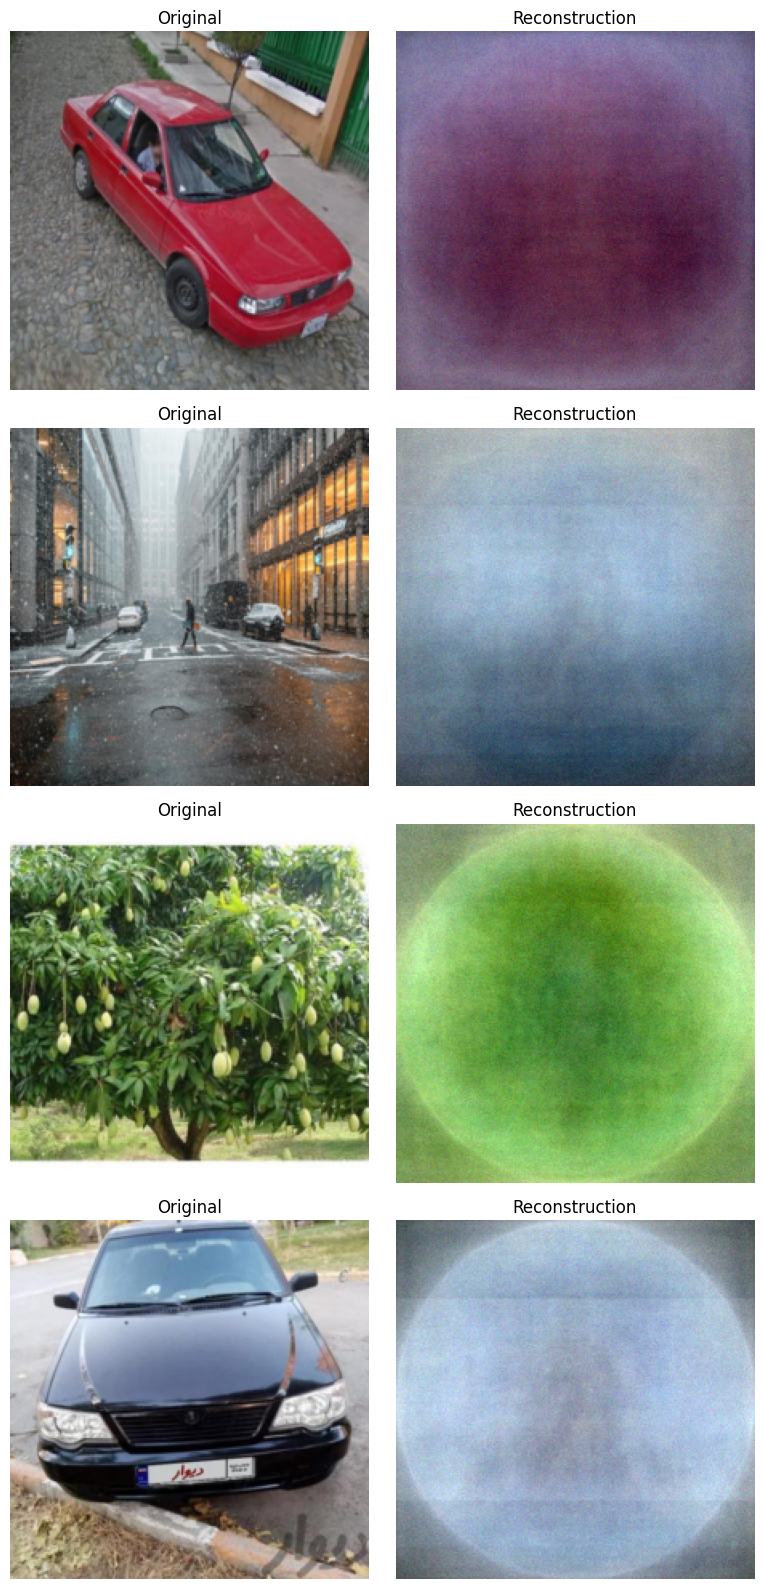

In [21]:
fig, ax = plt.subplots(
    4,
    2,
    figsize=(8, 16)
)

for i in range(4):

    original = denormalize(
        sample_images[i]
    )

    reconstruction = denormalize(
        reconstructed_images[i]
    )

    ax[i, 0].imshow(
        original.permute(1,2,0)
    )

    ax[i, 0].set_title(
        "Original"
    )

    ax[i, 0].axis("off")

    ax[i, 1].imshow(
        reconstruction.permute(1,2,0)
    )

    ax[i, 1].set_title(
        "Reconstruction"
    )

    ax[i, 1].axis("off")

plt.tight_layout()

plt.show()